In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import requests

In [2]:
array = np.zeros((3,4) , dtype=int)
print(array)

[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


In [3]:
array1 = np.ones((5,6) , dtype=int)
print(array1)

[[1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]]


In [8]:
array2 = np.random.random((3,4))
print(array2)

[[0.98112706 0.78095071 0.51397738 0.82875181]
 [0.6644149  0.36365042 0.21746419 0.93617729]
 [0.12693395 0.02684888 0.87876698 0.55308248]]


In [13]:
data = pd.read_csv(r"C:\Users\SriniAchuthan\OneDrive\Desktop\Machine-Learning-A-Z-Codes-Datasets\Machine Learning A-Z\Part 4 - Clustering\Section 24 - K-Means Clustering\Python\Mall_Customers.csv")
df = data.dropna()

In [11]:
print(df.isnull())

     CustomerID  Genre    Age  Annual Income (k$)  Spending Score (1-100)
0         False  False  False               False                   False
1         False  False  False               False                   False
2         False  False  False               False                   False
3         False  False  False               False                   False
4         False  False  False               False                   False
..          ...    ...    ...                 ...                     ...
195       False  False  False               False                   False
196       False  False  False               False                   False
197       False  False  False               False                   False
198       False  False  False               False                   False
199       False  False  False               False                   False

[200 rows x 5 columns]


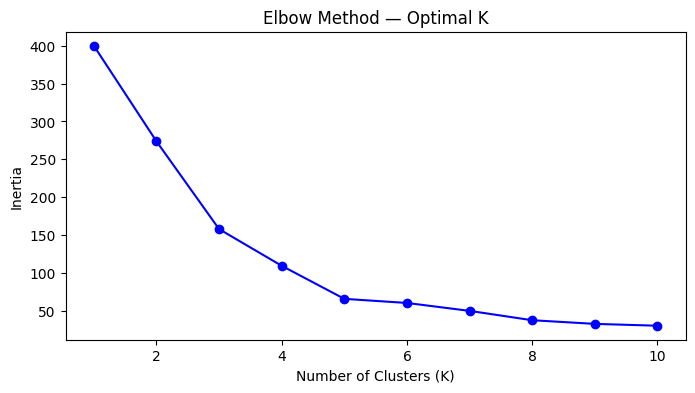

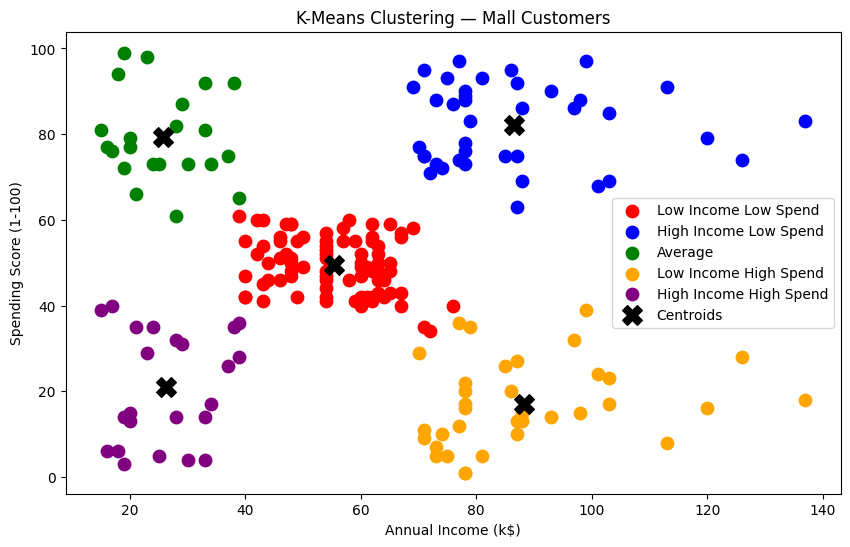

In [17]:
  # ── Correct column names ──
from sklearn.cluster import KMeans
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

  # Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

  # ── Elbow Method ──
inertia = []
for k in range(1, 11):
      km = KMeans(n_clusters=k, random_state=42)
      km.fit(X_scaled)
      inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o', color='blue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.show()

  # ── Apply K-Means K=5 ──
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

  # ── Visualize Clusters ──
colors = ['red', 'blue', 'green', 'orange', 'purple']
labels = ['Low Income Low Spend', 'High Income Low Spend',
            'Average', 'Low Income High Spend', 'High Income High Spend']

plt.figure(figsize=(10, 6))
for i in range(5):
      cluster_data = df[df['Cluster'] == i]
      plt.scatter(cluster_data['Annual Income (k$)'],
                  cluster_data['Spending Score (1-100)'],
                  c=colors[i], label=labels[i], s=80)

  # ── Plot Centroids ──
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
              c='black', marker='X', s=200, label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering — Mall Customers')
plt.legend()
plt.show()
